In [2]:
import pandas as pd

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [4]:
age = np.random.randint(18,65,200)
discount = np.random.randint(0,40,200)
z = (age * 0.1) + (discount * 0.2) - 6
probabilities = 1 / (1 + np.exp(-z))
bought = (probabilities > 0.5).astype(int)
df = pd.DataFrame({
    'Age': age,
    'Discount': discount,
    'Sales': bought
})
df.head()

,Age,Discount,Sales
0,36,30,1
1,23,35,1
2,32,17,1
3,35,23,1
4,30,17,1


In [5]:
X = df[['Age','Discount']] 
y = df['Sales']


In [6]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)
print(X_train.shape,X_test.shape)

(160, 2) (40, 2)


In [7]:
model = LogisticRegression()
model.fit(X_train, y_train)
print("Data readed succesfully")

Data readed succesfully


In [8]:
predict = model.predict(X_test)
predict

array([1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1])

In [9]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [10]:
correct_answer = accuracy_score(y_test, predict)
print(correct_answer * 100 , "%")

95.0 %


In [11]:
cm = confusion_matrix(y_test, predict)
print(cm)

[[12  2]
 [ 0 26]]


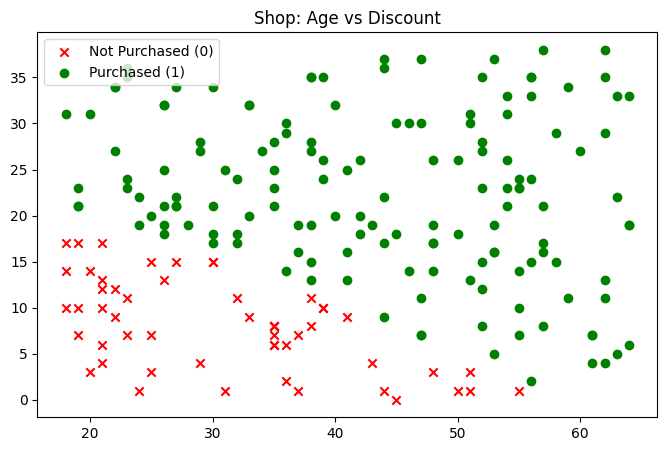

In [12]:

plt.figure(figsize=(8, 5))

nahi_kharida = df[df['Sales'] == 0]
plt.scatter(nahi_kharida['Age'], nahi_kharida['Discount'], color='red', marker='x', label='Not Purchased (0)')

kharida = df[df['Sales'] == 1]
plt.scatter(kharida['Age'], kharida['Discount'], color='green', marker='o', label='Purchased (1)')

plt.title('Shop: Age vs Discount')
plt.legend()
plt.show()

In [13]:
import seaborn as sns

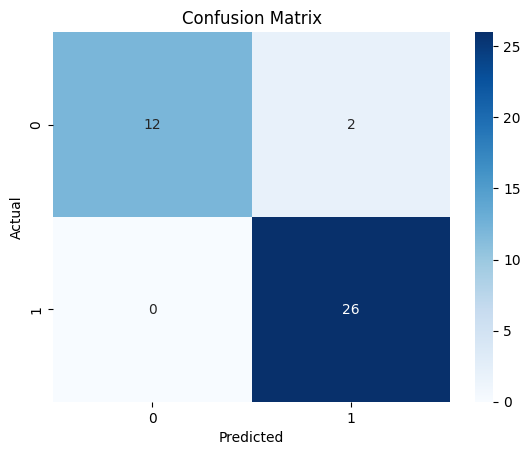

In [14]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()